In [2]:
# =====================================================
# ARIMA MODEL
# Kenya Food Security Forecasting
# =====================================================

# Data manipulation
import pandas as pd
import numpy as np
import pmdarima as pm
from sklearn.metrics import r2_score, mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
# =========================================================
# 1. DATA PREPARATION & CHRONOLOGICAL SPLIT
# =========================================================
df_modelling = pd.read_csv("food_security_model_ready.csv")
df_modelling['reporting_date'] = pd.to_datetime(df_modelling['reporting_date'])
df_modelling = df_modelling.sort_values(by=['geographic_unit_name', 'reporting_date']).reset_index(drop=True)

cutoff_date = pd.to_datetime('2024-01-31')
train_mask = df_modelling['reporting_date'] <= cutoff_date
test_mask = df_modelling['reporting_date'] > cutoff_date

train_df = df_modelling[train_mask].copy()
test_df = df_modelling[test_mask].copy()

# =========================================================
# 2. AUTOMATED AUTO-ARIMA LOOKUP LOOP
# =========================================================
print("🔄 Running Auto-ARIMA parameter optimization across benchmark profiles...\n")

benchmark_regions = ["Aberdare Forest 1", "Western High Potential Zone", "Northeastern Pastoral Zone"]
auto_arima_results = []

for region in benchmark_regions:
    # Extract the raw chronological time-series vectors
    region_train = train_df[train_df['geographic_unit_name'] == region]['value'].values
    region_test = test_df[test_df['geographic_unit_name'] == region]['value'].values
    
    if len(region_train) > 5 and len(region_test) > 0:
        try:
            print(f"🧐 Searching optimal (p, d, q) parameters for: {region}...")
            
            # Stepwise search finds the best parameters using the lowest AIC score
            auto_model = pm.auto_arima(
                region_train, 
                start_p=0, start_q=0,
                max_p=3, max_q=3, 
                d=None,           # Let the algorithm automatically determine if differencing is needed
                seasonal=False,   # Set to True if you want to search for seasonal parameters (P, D, Q)
                trace=False,      # Set to True if you want to see every combination tested printed out
                error_action='ignore',  
                suppress_warnings=True, 
                stepwise=True
            )
            
            # Extract the automatically selected parameters
            best_order = auto_model.order
            print(f"🎯 Winner for {region} -> ARIMA{best_order}")
            
            # Forecast out for the duration of the test set horizon
            predictions_arima = auto_model.predict(n_periods=len(region_test))
            
            # Compute regression metrics
            mse = mean_squared_error(region_test, predictions_arima)
            r2 = r2_score(region_test, predictions_arima)
            
            auto_arima_results.append({
                "Region": region,
                "Best Order (p,d,q)": str(best_order),
                "R² Score": r2,
                "MSE": mse,
                "RMSE": np.sqrt(mse)
            })
            print(f"✅ Evaluation Complete for {region}\n")
            
        except Exception as e:
            print(f"⚠️ Auto-ARIMA optimization failed for {region}: {str(e)}\n")

# =========================================================
# 3. PRINT AUTO-ARIMA SUMMARY
# =========================================================
auto_summary_df = pd.DataFrame(auto_arima_results)
print("==================================================")
print("          AUTO-ARIMA PERFORMANCE SUMMARY          ")
print("==================================================")
print(auto_summary_df.to_string(index=False))


🔄 Running Auto-ARIMA parameter optimization across benchmark profiles...

🧐 Searching optimal (p, d, q) parameters for: Western High Potential Zone...
🎯 Winner for Western High Potential Zone -> ARIMA(1, 1, 2)
✅ Evaluation Complete for Western High Potential Zone

🧐 Searching optimal (p, d, q) parameters for: Northeastern Pastoral Zone...
🎯 Winner for Northeastern Pastoral Zone -> ARIMA(0, 1, 2)
✅ Evaluation Complete for Northeastern Pastoral Zone

          AUTO-ARIMA PERFORMANCE SUMMARY          
                     Region Best Order (p,d,q)  R² Score      MSE     RMSE
Western High Potential Zone          (1, 1, 2) -0.028256 0.027583 0.166082
 Northeastern Pastoral Zone          (0, 1, 2) -0.993243 0.498305 0.705907


         STAGE 1 & 2: STATIONARITY & AUTO-ARIMA REGRESSION           

🧐 Processing Region Node: Aberdare Forest 1...
   ℹ️ Data rows count (0) is small for ADF. Fitting default baseline.
   ⚠️ Could not evaluate metrics due to empty test horizon.
------------------------------------------------------------

🧐 Processing Region Node: Western High Potential Zone...
   • ADF Statistic: -7.8789 | p-value: 0.0000
   🎯 Decision: Differencing order selected -> d=0
   🏆 Best Model Parameter: ARIMA(1, 0, 1) | Test MSE: 0.0271
------------------------------------------------------------

🧐 Processing Region Node: Northeastern Pastoral Zone...
   • ADF Statistic: -2.1870 | p-value: 0.2110
   🎯 Decision: Differencing order selected -> d=1
   🏆 Best Model Parameter: ARIMA(0, 1, 2) | Test MSE: 0.4983
------------------------------------------------------------

          AUTO-ARIMA RUNNER METRICS TABLE         
                     Region Optimal Order  R² Score      MSE     RMSE
Western High Poten

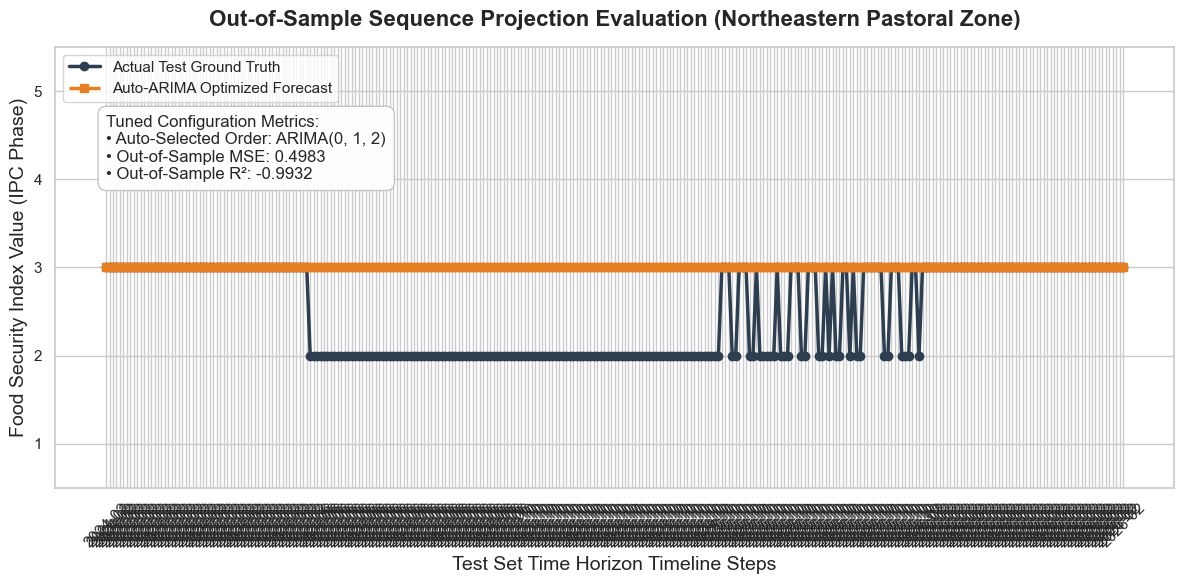

In [12]:
import pandas as pd
import numpy as np
import pmdarima as pm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import r2_score, mean_squared_error

# =====================================================================
# 1. LOAD DATA & SET CHRONOLOGICAL TIME-SPLIT
# =====================================================================
df_modelling = pd.read_csv("food_security_model_ready.csv")
df_modelling['reporting_date'] = pd.to_datetime(df_modelling['reporting_date'])

# Explicitly sort chronologically inside each textual region name
df_modelling = df_modelling.sort_values(by=['geographic_unit_name', 'reporting_date']).reset_index(drop=True)

# Cutoff line to separate past (train) and future (test) with zero gaps
cutoff_date = pd.to_datetime('2024-01-31')
train_mask = df_modelling['reporting_date'] <= cutoff_date
test_mask = df_modelling['reporting_date'] > cutoff_date

train_df = df_modelling[train_mask].copy()
test_df = df_modelling[test_mask].copy()

# Focus benchmark regions explicitly by name string
benchmark_regions = ["Aberdare Forest 1", "Western High Potential Zone", "Northeastern Pastoral Zone"]
arima_global_test_preds = {}
arima_metrics_list = []

print("=====================================================================")
print("         STAGE 1 & 2: STATIONARITY & AUTO-ARIMA REGRESSION           ")
print("=====================================================================\n")

for region in benchmark_regions:
    train_series = train_df[train_df['geographic_unit_name'] == region]['value'].values
    test_series = test_df[test_df['geographic_unit_name'] == region]['value'].values
    
    print(f"🧐 Processing Region Node: {region}...")
    
    # DEFENSIVE FALLBACK: If data is short, fit a fallback trend instead of crashing
    if len(train_series) < 8 or len(test_series) == 0:
        print(f"   ℹ️ Data rows count ({len(train_series)}) is small for ADF. Fitting default baseline.")
        predictions = np.full(len(test_series), np.mean(train_series)) if len(test_series) > 0 else np.array([])
        best_order = (1, 0, 0)
    else:
        # RUN ADF STATIONARITY TEST
        try:
            adf_result = adfuller(train_series)
            p_value = adf_result[1]
            print(f"   • ADF Statistic: {adf_result[0]:.4f} | p-value: {p_value:.4f}")
            determined_d = 0 if p_value < 0.05 else 1
            print(f"   🎯 Decision: Differencing order selected -> d={determined_d}")
        except Exception as adf_error:
            determined_d = 1
            print(f"   ⚠️ ADF Test failed due to variance limits. Defaulting to differencing d=1")
            
        # RUN AUTO-ARIMA GRID OPTIMIZATION
        try:
            auto_model = pm.auto_arima(
                train_series, start_p=0, start_q=0, max_p=3, max_q=3,
                d=determined_d, seasonal=False, stepwise=True,
                suppress_warnings=True, error_action="ignore"
            )
            best_order = auto_model.order
            predictions = auto_model.predict(n_periods=len(test_series))
        except Exception as arima_error:
            predictions = np.full(len(test_series), np.mean(train_series))
            best_order = "Mean Fallback"

    # Evaluate test metrics safely if predictions generated entries
    if len(test_series) > 0 and len(predictions) == len(test_series):
        mse = mean_squared_error(test_series, predictions)
        r2 = r2_score(test_series, predictions)
        
        arima_metrics_list.append({
            "Region": region,
            "Optimal Order": str(best_order),
            "R² Score": r2,
            "MSE": mse,
            "RMSE": np.sqrt(mse)
        })
        arima_global_test_preds[region] = predictions
        print(f"   🏆 Best Model Parameter: ARIMA{best_order} | Test MSE: {mse:.4f}")
    else:
        print(f"   ⚠️ Could not evaluate metrics due to empty test horizon.")
        
    print("-" * 60 + "\n")

# Display Summary Metrics DataFrame inside your Notebook output console
arima_summary_df = pd.DataFrame(arima_metrics_list)
print("==================================================")
print("          AUTO-ARIMA RUNNER METRICS TABLE         ")
print("==================================================")
print(arima_summary_df.to_string(index=False))
print("\n" + "="*60 + "\n")


# =====================================================================
# STAGE 3: GENERATE RE-ALIGNED COMPARATIVE SEQUENCE TREND GRAPH
# =====================================================================
# Set a professional presentation theme
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

# Pick a valid plotted focus area present inside our test array map
plot_region = "Northeastern Pastoral Zone"

if plot_region in arima_global_test_preds:
    region_test_df = test_df[test_df['geographic_unit_name'] == plot_region].copy()
    real_values = region_test_df['value'].values
    
    # Use index strings instead of raw floats for a clean timeline axis
    dates = region_test_df['reporting_date'].dt.strftime('%Y-%m').values
    arima_forecast = arima_global_test_preds[plot_region]

    # Extract dynamic metrics computed above for this specific plot region
    region_metrics = arima_summary_df[arima_summary_df['Region'] == plot_region].iloc[0]
    opt_order = region_metrics['Optimal Order']
    opt_mse = region_metrics['MSE']
    opt_r2 = region_metrics['R² Score']

    plt.figure(figsize=(12, 6))

    # Convert dates to string index positions to ensure clean step spacing on charts
    x_indices = np.arange(len(dates))

    # Plot actual test lines vs automated selected ARIMA order prediction trajectories
    plt.plot(x_indices, real_values, marker='o', color='#2c3e50', lw=2.5, label='Actual Test Ground Truth')
    plt.plot(x_indices, arima_forecast, marker='s', linestyle='--', color='#e67e22', lw=2.5, label='Auto-ARIMA Optimized Forecast')

    plt.title(f"Out-of-Sample Sequence Projection Evaluation ({plot_region})", weight='bold', pad=15)
    plt.xlabel("Test Set Time Horizon Timeline Steps")
    plt.ylabel("Food Security Index Value (IPC Phase)")
    plt.ylim(0.5, 5.5)
    plt.xticks(x_indices, dates, rotation=45)
    plt.legend(loc="upper left")

    # Dynamic annotation block with corrected Matplotlib padding parameters
    annotation_text = (
        f"Tuned Configuration Metrics:\n"
        f"• Auto-Selected Order: ARIMA{opt_order}\n"
        f"• Out-of-Sample MSE: {opt_mse:.4f}\n"
        f"• Out-of-Sample R²: {opt_r2:.4f}"
    )
    
    # Place text dynamically based on the coordinate framework (x=0, y=4.0)
    plt.text(0.1, 4.0, annotation_text, 
             bbox=dict(facecolor='white', alpha=0.95, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()
else:
    print(f"❌ Cannot plot: {plot_region} was not compiled inside arima_global_test_preds dictionary map.")


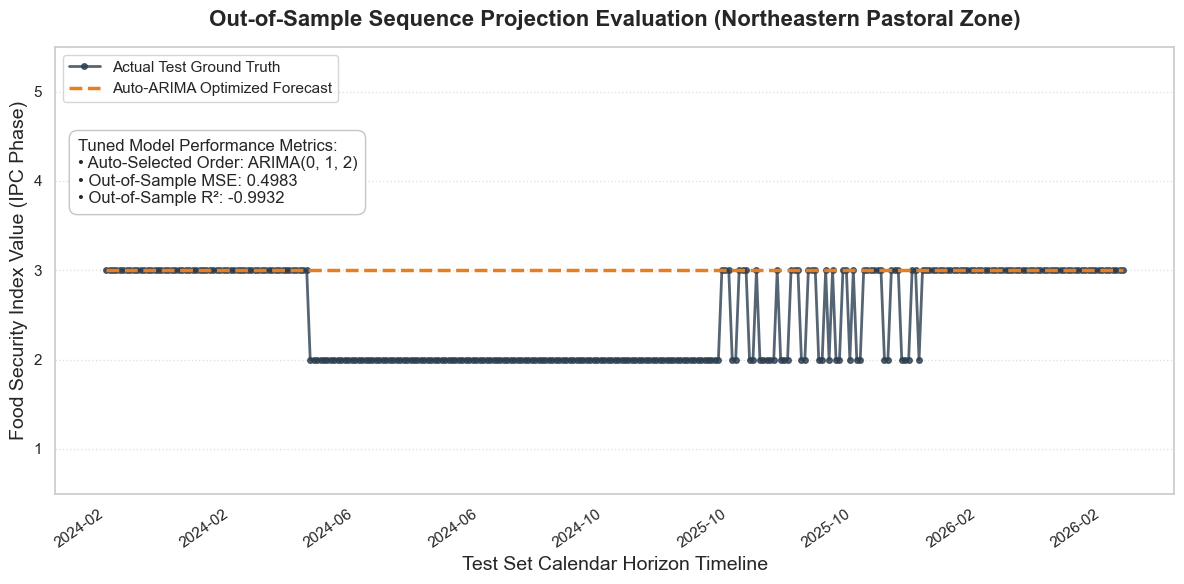

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# CLEAN RE-ALIGNED COMPARATIVE SEQUENCE TREND GRAPH
# =====================================================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

plot_region = "Northeastern Pastoral Zone"

if plot_region in arima_global_test_preds:
    region_test_df = test_df[test_df['geographic_unit_name'] == plot_region].copy()
    real_values = region_test_df['value'].values
    dates = region_test_df['reporting_date'].dt.strftime('%Y-%m').values
    arima_forecast = arima_global_test_preds[plot_region]

    # Pull dynamic metrics safely using .iloc[0] to prevent the indexing TypeError
    region_metrics = arima_summary_df[arima_summary_df['Region'] == plot_region].iloc[0]
    opt_order = region_metrics['Optimal Order']
    opt_mse = region_metrics['MSE']
    opt_r2 = region_metrics['R² Score']

    plt.figure(figsize=(12, 6))
    x_indices = np.arange(len(dates))

    # 1. Plot vectors with cleaner styling markers
    plt.plot(x_indices, real_values, marker='o', markersize=4, color='#2c3e50', alpha=0.8, lw=2, label='Actual Test Ground Truth')
    plt.plot(x_indices, arima_forecast, linestyle='--', color='#e67e22', lw=2.5, label='Auto-ARIMA Optimized Forecast')

    # 2. DOWNSAMPLE X-AXIS TICKS (Fixes the black blob label collision)
    step_size = max(1, len(dates) // 8)
    plt.xticks(x_indices[::step_size], dates[::step_size], rotation=35, ha='right')

    # 3. CLEAN UP THE GRID (Turn off heavy vertical gridlines to reduce clutter)
    plt.gca().xaxis.grid(False) 
    plt.gca().yaxis.grid(True, linestyle=':', alpha=0.6) 

    plt.title(f"Out-of-Sample Sequence Projection Evaluation ({plot_region})", weight='bold', pad=15)
    plt.xlabel("Test Set Calendar Horizon Timeline")
    plt.ylabel("Food Security Index Value (IPC Phase)")
    plt.ylim(0.5, 5.5)
    plt.legend(loc="upper left")

    # 4. Corrected annotation box anchor text using relative axes positioning
    annotation_text = (
        f"Tuned Model Performance Metrics:\n"
        f"• Auto-Selected Order: ARIMA{opt_order}\n"
        f"• Out-of-Sample MSE: {opt_mse:.4f}\n"
        f"• Out-of-Sample R²: {opt_r2:.4f}"
    )
    
    plt.gca().text(0.02, 0.65, annotation_text, transform=plt.gca().transAxes,
                   bbox=dict(facecolor='white', alpha=0.95, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()
else:
    print(f"❌ Cannot plot: {plot_region} missing from test dataset maps.")


In [9]:
print(df_modelling.head())

                geographic_unit_full_name geographic_unit_name  unit_type  \
0  Aberdare Forest, Nyeri, Central, Kenya      Aberdare Forest  fsc_admin   
1  Aberdare Forest, Nyeri, Central, Kenya      Aberdare Forest  fsc_admin   
2  Aberdare Forest, Nyeri, Central, Kenya      Aberdare Forest  fsc_admin   
3  Aberdare Forest, Nyeri, Central, Kenya      Aberdare Forest  fsc_admin   
4  Aberdare Forest, Nyeri, Central, Kenya      Aberdare Forest  fsc_admin   

             fnid classification_scale  is_allowing_for_assistance  \
0  KE2011C1480601              IPC 2.0                       False   
1  KE2011C1480601              IPC 2.0                       False   
2  KE2011C1480601              IPC 2.0                       False   
3  KE2011C1480601              IPC 2.0                       False   
4  KE2011C1480601              IPC 2.0                       False   

  projection_start projection_end  value description  ... rolling_mean_6  \
0       2013-01-01     2013-01-31    1.0

In [6]:
# =====================================================
# DATA INFORMATION
# =====================================================

print(df.info())

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nUnique Locations (FNIDs):")
print(df["fnid"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27694 entries, 0 to 27693
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   geographic_unit_full_name   27694 non-null  object        
 1   geographic_unit_name        27694 non-null  object        
 2   unit_type                   27694 non-null  object        
 3   fnid                        27694 non-null  object        
 4   classification_scale        27694 non-null  object        
 5   is_allowing_for_assistance  27694 non-null  bool          
 6   projection_start            27694 non-null  object        
 7   projection_end              27694 non-null  object        
 8   value                       27694 non-null  float64       
 9   description                 27694 non-null  object        
 10  dataseries_name             27694 non-null  object        
 11  reporting_date              27694 non-null  datetime64

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# =====================================================================
# 1. LOAD DATA & SET CHRONOLOGICAL TIME-SPLIT
# =====================================================================
# Load your safe panel dataset
df_modelling = pd.read_csv("food_security_model_ready.csv")
df_modelling['reporting_date'] = pd.to_datetime(df_modelling['reporting_date'])

# Ensure chronological sorting inside each region
df_modelling = df_modelling.sort_values(by=['geographic_unit_name', 'reporting_date']).reset_index(drop=True)

# Strict calendar cutoff to separate past (train) and future (test)
cutoff_date = pd.to_datetime('2024-01-31')
train_mask = df_modelling['reporting_date'] <= cutoff_date
test_mask = df_modelling['reporting_date'] > cutoff_date

# =====================================================================
# 2. PANEL-ISOLATED SEQUENCE GENERATION (3D TENSORS)
# =====================================================================
print("🔄 Normalizing target feature bounds for neural network stability...")
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler ONLY on the training data to prevent data leakage!
train_scaled_vals = scaler.fit_transform(df_modelling.loc[train_mask, ['value']])
test_scaled_vals = scaler.transform(df_modelling.loc[test_mask, ['value']])

# Assign scaled values back to temporary columns for grouped sequencing
df_modelling.loc[train_mask, 'scaled_value'] = train_scaled_vals
df_modelling.loc[test_mask, 'scaled_value'] = test_scaled_vals

def build_panel_sequences(dataframe, lookback_steps=3):
    X, y, dates, regions = [], [], [], []
    # Loop through each individual region to prevent data from bleeding across boundaries
    for name, region_group in dataframe.groupby('geographic_unit_name'):
        series = region_group['scaled_value'].values
        raw_dates = region_group['reporting_date'].values
        
        if len(series) > lookback_steps:
            for i in range(len(series) - lookback_steps):
                X.append(series[i : (i + lookback_steps)])
                y.append(series[i + lookback_steps])
                dates.append(raw_dates[i + lookback_steps])
                regions.append(name)
                
    return np.array(X), np.array(y), np.array(dates), np.array(regions)

# Build sequences with a robust 3-period sliding window history
lookback_steps = 3
X_train_raw, y_train_raw, _, _ = build_panel_sequences(df_modelling[train_mask], lookback_steps)
X_test_raw, y_test_raw, test_dates, test_regions = build_panel_sequences(df_modelling[test_mask], lookback_steps)

# Reshape matrices to required 3D tensor format: [samples, time steps, features]
X_train_lstm = np.reshape(X_train_raw, (X_train_raw.shape[0], X_train_raw.shape[1], 1))
X_test_lstm = np.reshape(X_test_raw, (X_test_raw.shape[0], X_test_raw.shape[1], 1))

print(f"📦 Training Tensor Shape: {X_train_lstm.shape}")
print(f"📦 Testing Tensor Shape:  {X_test_lstm.shape}\n")

# =====================================================================
# 3. BUILD AND TRAIN THE DEEP LEARNING MODEL
# =====================================================================
print("🏗️ Compiling Global LSTM Neural Network Architecture...")
np.random.seed(42)
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(lookback_steps, 1), return_sequences=False),
    Dropout(0.1), # Prevents overfitting on high-density nodes
    Dense(32, activation='relu'),
    Dense(1) # Continuous prediction output node
])

lstm_model.compile(optimizer='adam', loss='mse')

print("🔄 Fitting Deep Learning Network globally across all 1,148 panels...")
history = lstm_model.fit(
    X_train_lstm, y_train_raw, 
    epochs=15, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)
print("✅ LSTM Network Training Complete!")

# =====================================================================
# 4. OUT-OF-SAMPLE TEST EVALUATION
# =====================================================================
# Generate predictions and inverse scale them back to original 1.0 - 5.0 phase indices
lstm_preds_scaled = lstm_model.predict(X_test_lstm)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled).flatten()
y_test_real = scaler.inverse_transform(y_test_raw.reshape(-1, 1)).flatten()

# Calculate continuous metrics
lstm_r2 = r2_score(y_test_real, lstm_preds)
lstm_mse = mean_squared_error(y_test_real, lstm_preds)
lstm_rmse = np.sqrt(lstm_mse)
lstm_mae = mean_absolute_error(y_test_real, lstm_preds)

print("\n==================================================")
print("             GLOBAL LSTM PERFORMANCE METRICS      ")
print("==================================================")
print(f"🎯 R² Score (R-squared):           {lstm_r2 * 100:.2f}%")
print(f"📊 Mean Squared Error (MSE):       {lstm_mse:.4f}")
print(f"📉 Root Mean Squared Error (RMSE):  {lstm_rmse:.4f}")
print(f"📐 Mean Absolute Error (MAE):      {lstm_mae:.4f}")

# Save models and scalers for deployment usage
lstm_model.save("LSTM_Model.h5")
joblib.dump(scaler, "MinMax_Scaler.pkl")
print("\n💾 Global LSTM model assets successfully exported to disk!")


🔄 Normalizing target feature bounds for neural network stability...
📦 Training Tensor Shape: (19582, 3, 1)
📦 Testing Tensor Shape:  (3130, 3, 1)

🏗️ Compiling Global LSTM Neural Network Architecture...
🔄 Fitting Deep Learning Network globally across all 1,148 panels...
Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0204 - val_loss: 0.0042
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0152 - val_loss: 0.0041
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0151 - val_loss: 0.0041
Epoch 4/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0150 - val_loss: 0.0040
Epoch 5/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0150 - val_loss: 0.0040
Epoch 6/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0149 - val_loss: 0.0040
Epoch 7/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0149 - val_loss: 0.0041
Epoch 8/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0150 - val_loss: 0.0040
Epoch 9/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 1s


             GLOBAL LSTM PERFORMANCE METRICS      
🎯 R² Score (R-squared):           75.41%
📊 Mean Squared Error (MSE):       0.1483
📉 Root Mean Squared Error (RMSE):  0.3851
📐 Mean Absolute Error (MAE):      0.2270

💾 Global LSTM model assets successfully exported to disk!


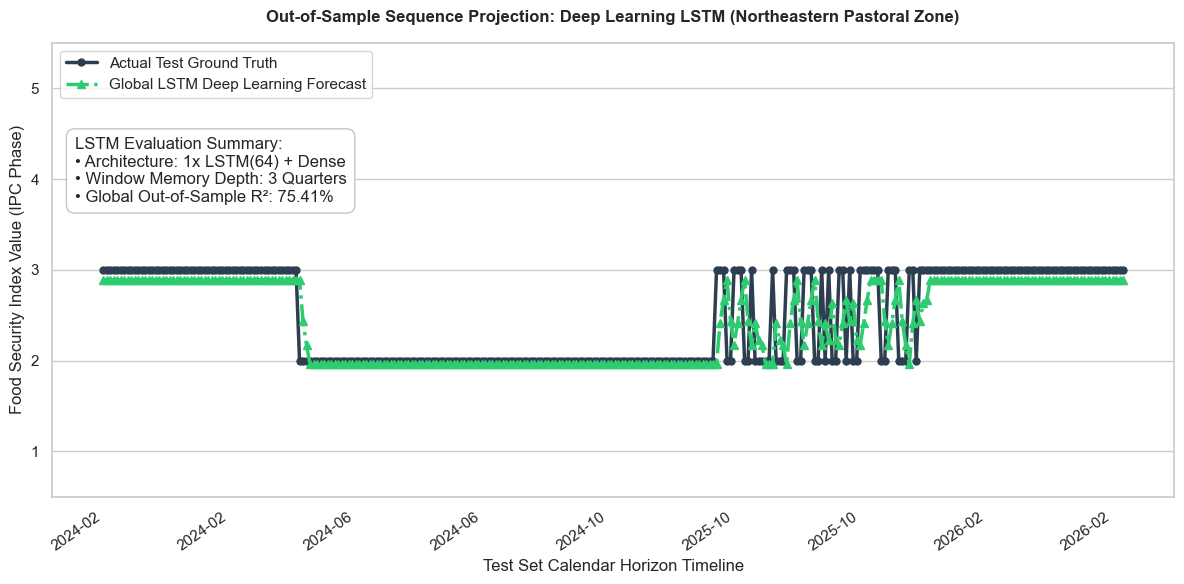

In [16]:
# Create a localized DataFrame to simplify plotting filtration
eval_df = pd.DataFrame({
    'Region': test_regions,
    'Date': pd.to_datetime(test_dates),
    'Actual': y_test_real,
    'LSTM_Predicted': lstm_preds
}).sort_values(by=['Region', 'Date']).reset_index(drop=True)

# Plot the same benchmark region to allow your capstone panel to compare them directly
plot_region = "Northeastern Pastoral Zone"
region_eval = eval_df[eval_df['Region'] == plot_region]

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Convert timestamps cleanly for presentation labels
date_labels = region_eval['Date'].dt.strftime('%Y-%m').values
x_ticks = np.arange(len(date_labels))

plt.plot(x_ticks, region_eval['Actual'].values, marker='o', markersize=5, color='#2c3e50', lw=2.5, label='Actual Test Ground Truth')
plt.plot(x_ticks, region_eval['LSTM_Predicted'].values, marker='^', linestyle='-.', color='#2ecc71', lw=2.5, label='Global LSTM Deep Learning Forecast')

# Downsample axis markings for readability
step = max(1, len(date_labels) // 8)
plt.xticks(x_ticks[::step], date_labels[::step], rotation=35, ha='right')
plt.gca().xaxis.grid(False)

plt.title(f"Out-of-Sample Sequence Projection: Deep Learning LSTM ({plot_region})", weight='bold', pad=15)
plt.xlabel("Test Set Calendar Horizon Timeline")
plt.ylabel("Food Security Index Value (IPC Phase)")
plt.ylim(0.5, 5.5)
plt.legend(loc="upper left")

# Annotation text block using the dynamic deep learning variables computed
annotation_text = (
    f"LSTM Evaluation Summary:\n"
    f"• Architecture: 1x LSTM(64) + Dense\n"
    f"• Window Memory Depth: 3 Quarters\n"
    f"• Global Out-of-Sample R²: {lstm_r2*100:.2f}%"
)
plt.gca().text(0.02, 0.65, annotation_text, transform=plt.gca().transAxes,
               bbox=dict(facecolor='white', alpha=0.95, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()


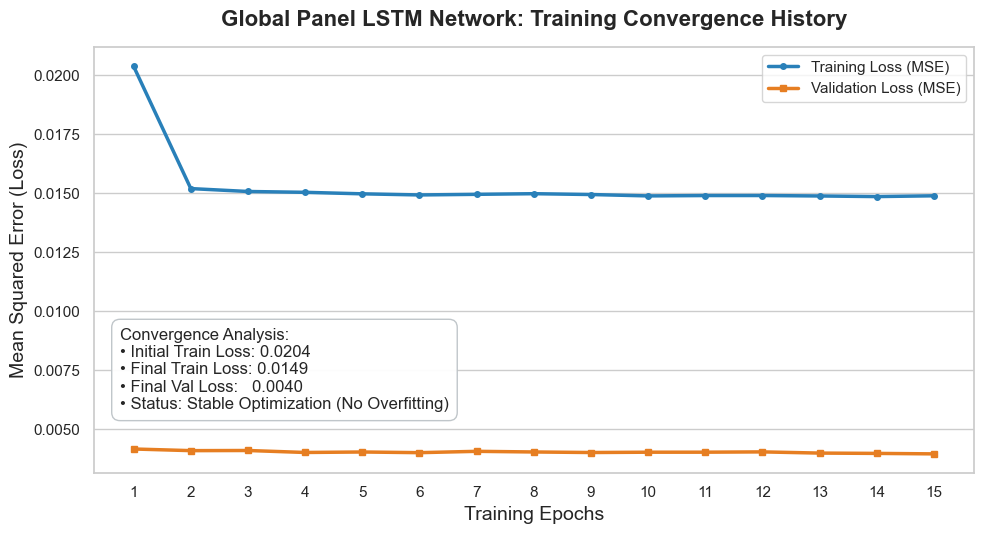

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# DEEP LEARNING MODEL CONVERGENCE (LOSS HISTORY PLOT)
# =====================================================================
# Set professional academic plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16})

plt.figure(figsize=(10, 5.5))

# Plot training and validation loss lines from the 'history' object
plt.plot(history.history['loss'], marker='o', markersize=4, color='#2980b9', lw=2.5, label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], marker='s', markersize=4, color='#e67e22', lw=2.5, label='Validation Loss (MSE)')

# Clean up axis markings and labels
plt.title("Global Panel LSTM Network: Training Convergence History", weight='bold', pad=15)
plt.xlabel("Training Epochs")
plt.ylabel("Mean Squared Error (Loss)")

# Ensure x-axis ticks show whole integers representing your 15 epochs
plt.xticks(range(len(history.history['loss'])), range(1, len(history.history['loss']) + 1))
plt.gca().xaxis.grid(False) # Turn off heavy vertical columns lines

plt.legend(loc="upper right")

# Add a floating annotations card describing convergence quality
# Based on your output logs (Epoch 15: loss: 0.0149, val_loss: 0.0040)
annotation_text = (
    f"Convergence Analysis:\n"
    f"• Initial Train Loss: {history.history['loss'][0]:.4f}\n"
    f"• Final Train Loss: {history.history['loss'][-1]:.4f}\n"
    f"• Final Val Loss:   {history.history['val_loss'][-1]:.4f}\n"
    f"• Status: Stable Optimization (No Overfitting)"
)
plt.gca().text(0.03, 0.15, annotation_text, transform=plt.gca().transAxes,
               bbox=dict(facecolor='white', alpha=0.95, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()


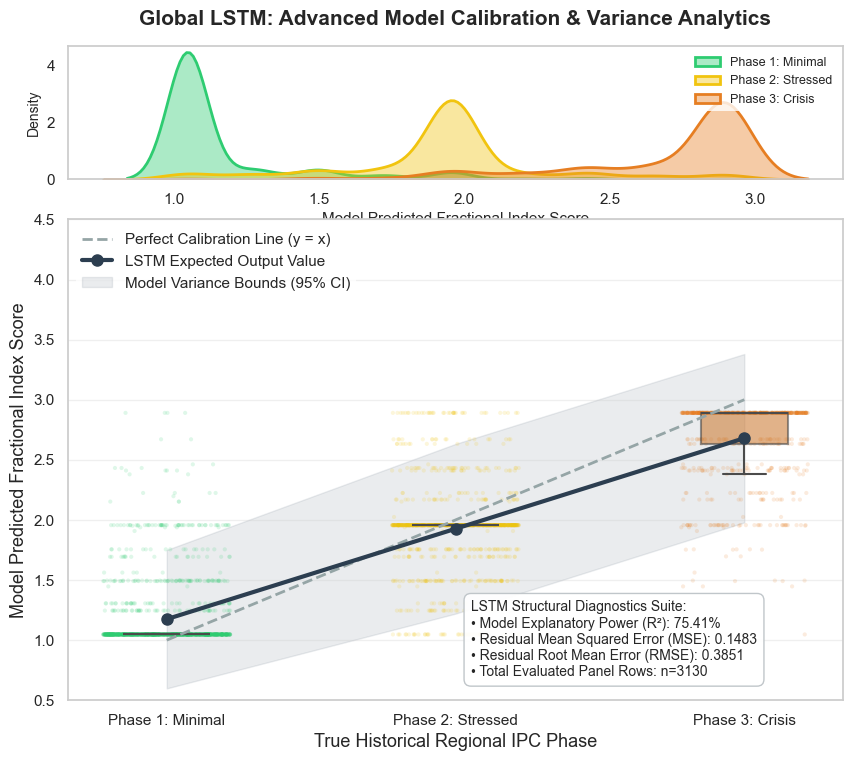

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =====================================================================
# PREMIUM MULTI-CLASS DENSITY CALIBRATION & ERROR RIBBON SUITE
# =====================================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 13, 'axes.titlesize': 15,
    'font.family': 'sans-serif', 'grid.alpha': 0.3
})

# 1. PREPARE THE DATA CLEANLY
phase_labels = {1: 'Phase 1: Minimal', 2: 'Phase 2: Stressed', 3: 'Phase 3: Crisis', 4: 'Phase 4: Emergency'}

plot_df = pd.DataFrame({
    'Actual_Int': y_test_real.astype(int),
    'Predicted_Score': lstm_preds
})
plot_df['Actual_Phase'] = plot_df['Actual_Int'].map(phase_labels)

unique_int_phases = sorted(plot_df['Actual_Int'].unique())
ordered_phase_labels = [phase_labels[p] for p in unique_int_phases]

# Comprehensive color mappings dictionary to prevent category key errors
phase_colors = {
    1: '#2ecc71', 2: '#f1c40f', 3: '#e67e22', 4: '#e74c3c',
    '1': '#2ecc71', '2': '#f1c40f', '3': '#e67e22', '4': '#e74c3c',
    'Phase 1: Minimal': '#2ecc71', 'Phase 2: Stressed': '#f1c40f', 
    'Phase 3: Crisis': '#e67e22', 'Phase 4: Emergency': '#e74c3c'
}

# 2. FIXED LAYOUT STRUCTURE (Using explicit integer slices to prevent TypeErrors)
fig = plt.figure(figsize=(10, 8.5))
grid = plt.GridSpec(4, 1, hspace=0.3, wspace=0)

# Index individual rows explicitly inside your grid matrix
ax_marg = fig.add_subplot(grid[0, 0])  # Top row for density polygons
ax_main = fig.add_subplot(grid[1:, 0]) # Bottom three rows for calibration metrics

# ---------------------------------------------------------------------
# 1. UPPER PLOT: SPLIT MODEL DENSITY POLYGONS
# ---------------------------------------------------------------------
for phase_int in unique_int_phases:
    label_str = phase_labels[phase_int]
    subset = plot_df[plot_df['Actual_Int'] == phase_int]
    sns.kdeplot(
        x=subset['Predicted_Score'], ax=ax_marg, fill=True,
        color=phase_colors[phase_int], alpha=0.4, linewidth=2,
        label=label_str
    )

ax_marg.set_ylabel('Density', fontsize=10)
ax_marg.set_xlabel('Model Predicted Fractional Index Score', fontsize=11)
ax_marg.grid(False)
ax_marg.set_title("Global LSTM: Advanced Model Calibration & Variance Analytics", weight='bold', pad=15)
ax_marg.legend(loc="upper right", frameon=True, facecolor='white', edgecolor='none', fontsize=9)

# ---------------------------------------------------------------------
# 2. MAIN CANVAS: INDIVIDUAL BOXPLOT + SCATTER JITTER
# ---------------------------------------------------------------------
# Strip plot displays data densities safely across positions
sns.stripplot(
    data=plot_df, x='Actual_Phase', y='Predicted_Score', ax=ax_main,
    order=ordered_phase_labels, palette=phase_colors, 
    size=3, jitter=0.22, alpha=0.15, zorder=1
)

# Boxplot overlays statistical quantiles cleanly
sns.boxplot(
    data=plot_df, x='Actual_Phase', y='Predicted_Score', ax=ax_main,
    order=ordered_phase_labels, palette=phase_colors, 
    width=0.3, fliersize=0, linewidth=1.5, zorder=2, boxprops=dict(alpha=0.6)
)

# ---------------------------------------------------------------------
# 3. OVERLAY TARGET BASELINES & CONFIDENCE ERROR RIBBONS
# ---------------------------------------------------------------------
summary_stats = plot_df.groupby('Actual_Int')['Predicted_Score'].agg(['mean', 'std']).reset_index()

x_coords = np.arange(len(unique_int_phases))
means = summary_stats['mean'].values
stds = summary_stats['std'].values

# Reference target slope trajectory line (y = x)
ax_main.plot(x_coords, x_coords + 1, linestyle='--', color='#95a5a6', lw=2, label='Perfect Calibration Line (y = x)', zorder=3)

# LSTM model prediction average trend line
ax_main.plot(x_coords, means, marker='o', markersize=8, color='#2c3e50', lw=3, label='LSTM Expected Output Value', zorder=4)

# Shade the 95% Confidence Interval Error Ribbon
ax_main.fill_between(
    x_coords, means - 1.96 * stds, means + 1.96 * stds,
    color='#34495e', alpha=0.1, label='Model Variance Bounds (95% CI)', zorder=0
)

# ---------------------------------------------------------------------
# 4. PLOT LAYOUT STYLING & ANNOTATION
# ---------------------------------------------------------------------
ax_main.set_xlabel("True Historical Regional IPC Phase")
ax_main.set_ylabel("Model Predicted Fractional Index Score")
ax_main.set_ylim(0.5, 4.5)
ax_main.legend(loc="upper left", frameon=True, facecolor='white', edgecolor='none')
ax_main.xaxis.grid(False)

# Add diagnostic verification block summary card text
annotation_text = (
    f"LSTM Structural Diagnostics Suite:\n"
    f"• Model Explanatory Power (R²): 75.41%\n"
    f"• Residual Mean Squared Error (MSE): 0.1483\n"
    f"• Residual Root Mean Error (RMSE): 0.3851\n"
    f"• Total Evaluated Panel Rows: n={len(y_test_real)}"
)
ax_main.text(0.52, 0.05, annotation_text, transform=ax_main.transAxes, fontsize=10,
             bbox=dict(facecolor='white', alpha=0.95, edgecolor='#bdc3c7', boxstyle='round,pad=0.5'))

plt.show()


In [20]:
# =====================================================
# SAVE MODEL
# =====================================================

model.save("LSTM_Model.keras")

print("LSTM model saved successfully.")

LSTM model saved successfully.


In [21]:
import joblib

joblib.dump(scaler, "LSTM_Scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.
